In [1]:
!pip install -q diffusers transformers accelerate omegaconf

In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1: Load pipeline (chạy 1 lần)
# ══════════════════════════════════════════════════════════════════

import torch, gc, re
import numpy as np
import cv2
from PIL import Image, ImageFilter
from diffusers import (
    StableDiffusionXLControlNetInpaintPipeline,
    ControlNetModel,
)
from diffusers.utils import load_image
from transformers import AutoTokenizer, AutoModelForCausalLM

pretrained = "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"

controlnet = ControlNetModel.from_pretrained(
    "diffusers/controlnet-depth-sdxl-1.0",
    torch_dtype=torch.float16,
)
pipe = StableDiffusionXLControlNetInpaintPipeline.from_pretrained(
    pretrained,
    controlnet=controlnet,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")

pipe.load_lora_weights(
    "/content/pytorch_lora_weights.safetensors"
)
pipe.set_adapters(["default_0"], adapter_weights=[0.8])

pipe.vae.enable_slicing()
pipe.set_progress_bar_config(disable=False)
print("✅ Pipeline ready (ControlNet depth + LoRA)")

# ── MiDaS Depth Estimator ────────────────────────────────────────
print("Loading MiDaS DPT-Hybrid...")
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Hybrid", trust_repo=True)
midas = midas.to("cuda").eval()
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms", trust_repo=True)
midas_transform = midas_transforms.dpt_transform
print("✅ MiDaS ready")

# ── Qwen3-4B ─────────────────────────────────────────────────────
print("Loading Qwen3-4B...")
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B")
qwen_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-4B", torch_dtype=torch.float16, device_map="cuda",
)
print("✅ Qwen3-4B ready")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1/snapshots/115134f363124c53c7d878647567d04daf26e41e/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ Qwen3-4B ready


In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 2: Helper Functions
# ══════════════════════════════════════════════════════════════════

def estimate_depth(pil_image: Image.Image) -> Image.Image:
    """
    Estimate depth via MiDaS DPT-Hybrid → returns RGB PIL Image.

    Output format matches training preprocessing:
    - Normalized to [0, 255]
    - 3-channel RGB (grayscale replicated — training code uses
      this as ControlNet input directly)
    """
    img_np = np.array(pil_image.convert("RGB"))
    h, w = img_np.shape[:2]

    input_batch = midas_transform(img_np).to("cuda")
    with torch.no_grad():
        prediction = midas(input_batch)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=(h, w),
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth = prediction.cpu().numpy()

    # Normalize to [0, 255]
    d_min, d_max = depth.min(), depth.max()
    if d_max - d_min > 1e-6:
        depth_norm = ((depth - d_min) / (d_max - d_min) * 255.0)
    else:
        depth_norm = np.zeros_like(depth)

    depth_uint8 = depth_norm.astype(np.uint8)
    depth_rgb = np.stack([depth_uint8] * 3, axis=-1)
    return Image.fromarray(depth_rgb)


def regularize_mask(mask_image, target_size, roundness_threshold=0.75):
    mask_np = np.array(mask_image.convert("L").resize(target_size, Image.NEAREST))
    _, binary = cv2.threshold(mask_np, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask_image.convert("L").resize(target_size, Image.NEAREST)
    contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    circularity = (4 * np.pi * area / perimeter**2) if perimeter > 0 else 0
    canvas = np.zeros_like(binary)
    if circularity >= roundness_threshold:
        (cx, cy), (ma, mb), angle = cv2.fitEllipse(contour)
        if min(ma, mb) / max(ma, mb) > 0.90:
            cv2.circle(canvas, (int(cx), int(cy)), int(max(ma, mb) / 2), 255, -1)
        else:
            cv2.ellipse(canvas, (int(cx), int(cy)), (int(ma/2), int(mb/2)),
                        angle, 0, 360, 255, -1)
    else:
        box = cv2.boxPoints(cv2.minAreaRect(contour)).astype(np.int32)
        cv2.fillPoly(canvas, [box], 255)
    return Image.fromarray(canvas)


def enhance_prompt(raw_prompt, max_clip_tokens=77):
    system = (
        "You are an expert Stable Diffusion prompt writer for interior design inpainting. "
        "As an interior design expert, please help me enhance the simple descriptions "
        "of an object into a detailed, vivid presentation of that object."
        "Given a enchance description, rewrite it into a detailed, high-quality prompt. "
        "Rules:\n1. Output ONLY the enhanced prompt\n2. Under 60 words\n"
        "3. Add: material, lighting, style, quality tags\n4. Comma-separated\n5. No quotes\n"
    )
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": f"Enhance this inpainting prompt: {raw_prompt}"},
    ]
    text = qwen_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
    )
    inputs = qwen_tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = qwen_model.generate(
            **inputs, max_new_tokens=120, temperature=0.7,
            top_p=0.9, do_sample=True,
        )
    enhanced = qwen_tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()
    enhanced = re.sub(r"<\s*think\s*>.*?<\s*/\s*think\s*>", "", enhanced, flags=re.DOTALL).strip()
    enhanced = re.sub(r"<\s*think\s*>.*", "", enhanced, flags=re.DOTALL).strip()
    enhanced = re.sub(r"<[^>]+>", "", enhanced).strip().strip('"\'')
    if not enhanced:
        return raw_prompt
    clip_ids = pipe.tokenizer.encode(enhanced)
    if len(clip_ids) > max_clip_tokens:
        enhanced = pipe.tokenizer.decode(
            clip_ids[:max_clip_tokens], skip_special_tokens=True
        )
    return enhanced


def inpaint_any_resolution(
    pipe, init_image, mask_image, depth_image,   # ★ THÊM depth_image
    prompt, negative_prompt,
    inpaint_size=1024, crop_padding=128,
    controlnet_conditioning_scale=0.5,            # ★ THÊM param
    **pipe_kwargs,
):
    """
    Crop vùng mask → inpaint VỚI depth conditioning → paste lại.

    ★ FIX CHÍNH: Truyền depth map vào control_image để ControlNet
    thực sự hoạt động thay vì nhận zero tensor.
    """
    W, H = init_image.size
    mask_np = np.array(mask_image.convert("L"))
    ys, xs = np.where(mask_np > 127)
    if len(xs) == 0:
        raise ValueError("Mask trống")

    # Crop region around mask (with padding)
    x1 = max(0, xs.min() - crop_padding)
    y1 = max(0, ys.min() - crop_padding)
    x2 = min(W, xs.max() + crop_padding)
    y2 = min(H, ys.max() + crop_padding)

    print(f"  Ảnh gốc : {W}×{H}")
    print(f"  Crop    : ({x1},{y1})→({x2},{y2}) [{x2-x1}×{y2-y1}]")

    crop_img   = init_image.convert("RGB").crop((x1, y1, x2, y2))
    crop_mask  = mask_image.convert("L").crop((x1, y1, x2, y2))
    crop_depth = depth_image.convert("RGB").crop((x1, y1, x2, y2))  # ★ NEW
    crop_w, crop_h = crop_img.size

    # Scale to inpaint_size (divisible by 64 for SDXL)
    scale = inpaint_size / max(crop_w, crop_h)
    inp_w = (int(crop_w * scale) // 64) * 64
    inp_h = (int(crop_h * scale) // 64) * 64

    inp_img   = crop_img.resize((inp_w, inp_h), Image.LANCZOS)
    inp_mask  = crop_mask.resize((inp_w, inp_h), Image.NEAREST)
    inp_depth = crop_depth.resize((inp_w, inp_h), Image.LANCZOS)   # ★ NEW

    print(f"  Inpaint : {inp_w}×{inp_h}")
    print(f"  ControlNet scale: {controlnet_conditioning_scale}")

    # ★ FIX: Truyền control_image + controlnet_conditioning_scale
    result_small = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=inp_img,
        mask_image=inp_mask,
        control_image=inp_depth,                                      # ★ ĐÂY
        controlnet_conditioning_scale=controlnet_conditioning_scale,   # ★ ĐÂY
        **pipe_kwargs,
    ).images[0]

    # Paste back to original resolution
    result_crop = result_small.resize((crop_w, crop_h), Image.LANCZOS)
    output = init_image.convert("RGB").copy()
    output.paste(
        result_crop, (x1, y1),
        mask=crop_mask.resize((crop_w, crop_h), Image.NEAREST),
    )
    return output


Ảnh gốc: 6720×4480
Generating depth...


preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/490M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/490M [00:00<?, ?B/s]

✅ Depth: (6720, 4480)
📝 Raw:      A round wooden wall clock
✨ Enhanced: round wooden wall clock, warm oak material, soft golden lighting, rustic style, high detail, realistic quality, interior design, vintage charm, hand-carved details, aged finish, subtle shadows, natural textures
  Ảnh gốc : 6720×4480
  Crop    : (3758,691)→(4472,1405) [714×714]
  Inpaint : 1024×1024


  0%|          | 0/47 [00:00<?, ?it/s]

🚀 Đang thực hiện Poisson Blending...


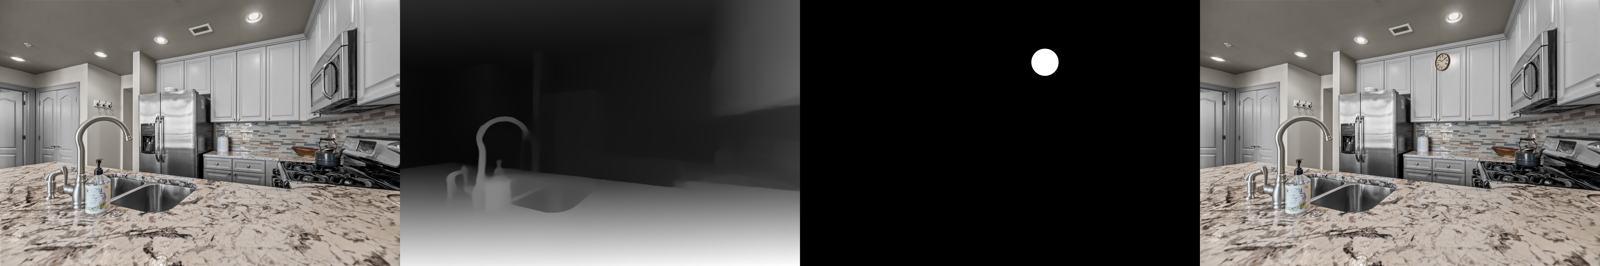

[Original | Depth | Mask | Result]
✅ Đã lưu kết quả!
Prompt: round wooden wall clock, warm oak material, soft golden lighting, rustic style, high detail, realistic quality, interior design, vintage charm, hand-carved details, aged finish, subtle shadows, natural textures


In [3]:
# ── Run ───────────────────────────────────────────────────────────
from transformers import DPTForDepthEstimation, DPTImageProcessor

init_image = load_image("/content/G.jpg").convert("RGB")
W, H = init_image.size
print(f"Ảnh gốc: {W}×{H}")

mask_image = regularize_mask(load_image("/content/mask_G1.png"), target_size=(W, H))

# ── Depth map (MiDaS) ────────────────────────────────────────────
print("Generating depth...")
dp = DPTImageProcessor.from_pretrained("Intel/dpt-hybrid-midas")
dm = DPTForDepthEstimation.from_pretrained("Intel/dpt-hybrid-midas", torch_dtype=torch.float16).to("cuda")
with torch.no_grad():
    pred = dm(**dp(images=init_image, return_tensors="pt").to("cuda", torch.float16)).predicted_depth
dt = torch.nn.functional.interpolate(
    pred.unsqueeze(1).float(), size=(H, W), mode="bicubic", align_corners=False
).squeeze()
dn = dt.cpu().numpy()
dn = (dn - dn.min()) / (dn.max() - dn.min() + 1e-8) * 255.0
depth_map = Image.fromarray(dn.astype(np.uint8)).convert("RGB")
del dm, dp; torch.cuda.empty_cache()
print(f"✅ Depth: {depth_map.size}")

# ── Prompt ────────────────────────────────────────────────────────
raw_prompt = "A round wooden wall clock"
prompt = enhance_prompt(raw_prompt)
negative_prompt = "low quality, blurry, distorted, deformed, floating, abstract, cartoon, artifacts"
print(f"📝 Raw:      {raw_prompt}")
print(f"✨ Enhanced: {prompt}")

torch.cuda.empty_cache(); gc.collect()

# ── Inpaint với depth (sửa function thêm depth_map) ──────────────
def inpaint_with_depth(pipe, init_image, mask_image, depth_map, prompt, negative_prompt,
                        inpaint_size=1024, crop_padding=128, **pipe_kwargs):
    """Crop vùng mask → inpaint VỚI depth → paste lại."""
    W, H = init_image.size
    mask_np = np.array(mask_image.convert("L"))
    ys, xs = np.where(mask_np > 127)
    if len(xs) == 0:
        raise ValueError("Mask trống")

    x1 = max(0, xs.min() - crop_padding)
    y1 = max(0, ys.min() - crop_padding)
    x2 = min(W, xs.max() + crop_padding)
    y2 = min(H, ys.max() + crop_padding)

    print(f"  Ảnh gốc : {W}×{H}")
    print(f"  Crop    : ({x1},{y1})→({x2},{y2}) [{x2-x1}×{y2-y1}]")

    # ★ Crop cả 3: image, mask, depth
    crop_img   = init_image.convert("RGB").crop((x1, y1, x2, y2))
    crop_mask  = mask_image.convert("L").crop((x1, y1, x2, y2))
    crop_depth = depth_map.convert("RGB").crop((x1, y1, x2, y2))
    crop_w, crop_h = crop_img.size

    scale = inpaint_size / max(crop_w, crop_h)
    inp_w = (int(crop_w * scale) // 64) * 64
    inp_h = (int(crop_h * scale) // 64) * 64

    inp_img   = crop_img.resize((inp_w, inp_h), Image.LANCZOS)
    inp_mask  = crop_mask.resize((inp_w, inp_h), Image.NEAREST)
    inp_depth = crop_depth.resize((inp_w, inp_h), Image.LANCZOS)

    print(f"  Inpaint : {inp_w}×{inp_h}")

    result_small = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=inp_img,
        mask_image=inp_mask,
        control_image=inp_depth,        # ★ depth conditioning
        height=inp_h,
        width=inp_w,
        **pipe_kwargs,
    ).images[0]

    result_crop = result_small.resize((crop_w, crop_h), Image.LANCZOS)
    output = init_image.convert("RGB").copy()
    output.paste(result_crop, (x1, y1), mask=crop_mask.resize((crop_w, crop_h), Image.NEAREST))
    return output

# ── Inpaint ───────────────────────────────────────────────────────
result_raw = inpaint_with_depth(
    pipe, init_image, mask_image, depth_map,
    prompt=prompt,
    negative_prompt=negative_prompt,
    inpaint_size=1024,
    crop_padding=128,
    strength=0.95,
    num_inference_steps=50,
    guidance_scale=8.0,
    controlnet_conditioning_scale=0.15,  # ★ thấp: gợi ý perspective, không ép
    generator=torch.Generator("cuda").manual_seed(42),
)

# ── Poisson Seamless Blend ────────────────────────────────────────
print("🚀 Đang thực hiện Poisson Blending...")

dst = cv2.cvtColor(np.array(init_image), cv2.COLOR_RGB2BGR)
src = cv2.cvtColor(np.array(result_raw), cv2.COLOR_RGB2BGR)
mask = np.array(mask_image.convert("L"))

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    center = (x + w // 2, y + h // 2)
    try:
        blended_cv = cv2.seamlessClone(src, dst, mask, center, cv2.NORMAL_CLONE)
        result = Image.fromarray(cv2.cvtColor(blended_cv, cv2.COLOR_BGR2RGB))
    except Exception as e:
        print(f"⚠️ Poisson Blend lỗi: {e}. Dùng ảnh inpaint gốc.")
        result = result_raw
else:
    result = result_raw

# ── Display (4 panel: Original | Depth | Mask | Result) ──────────
result.save("result_poisson.png")
combined = Image.new("RGB", (W * 4, H))
combined.paste(init_image,               (0,     0))
combined.paste(depth_map,                (W,     0))
combined.paste(mask_image.convert("RGB"), (W * 2, 0))
combined.paste(result,                   (W * 3, 0))

display(combined.resize((1600, int(1600 * H / (W * 4)))))
print(f"[Original | Depth | Mask | Result]")
print(f"✅ Đã lưu kết quả!")
print(f"Prompt: {prompt}")